In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Caricamento del dataset
df = pd.read_csv('C:\\Users\\ogiug\\Documents\\healthcare project\\data\\diabetes_dataset.csv')

# Visualizziamo le colonne per essere sicuri che tutto sia corretto
print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.")
df.head()

Il dataset contiene 100000 righe e 31 colonne.


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [10]:
# Controllo valori mancanti e duplicati
print(f"Valori mancanti:\n{df.isnull().sum().sum()}")
print(f"Righe duplicate: {df.duplicated().sum()}")

# Rinominiamo le colonne per renderle più leggibili se serve

df.columns = [col.replace('_', ' ').title() for col in df.columns]

Valori mancanti:
0
Righe duplicate: 0


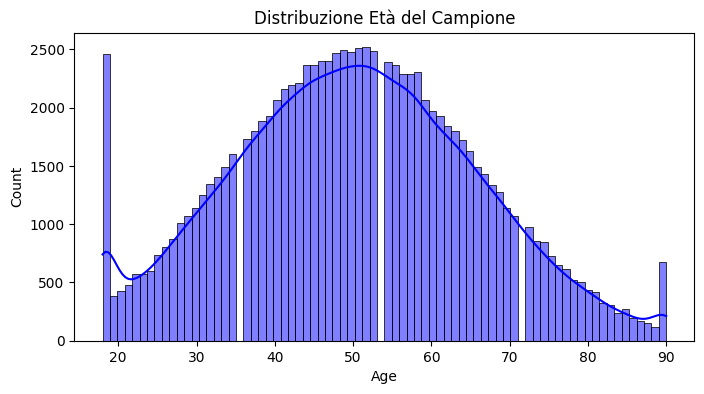

In [20]:
# Analisi rapida della distribuzione dell'età
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Distribuzione Età del Campione')
plt.show()

C:\Users\ogiug\AppData\Local\Temp\ipykernel_9792\1985000136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosed Diabetes', y='Bmi', data=df, palette='Set2')


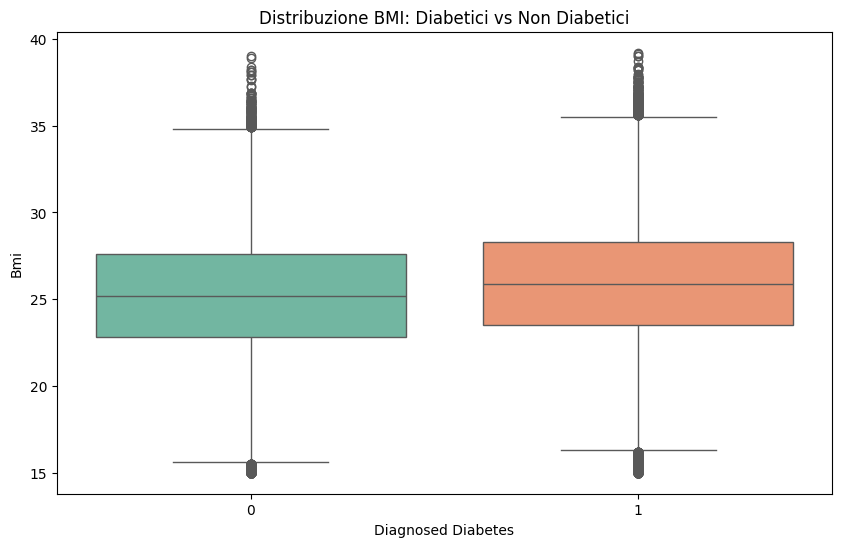

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diagnosed Diabetes', y='Bmi', data=df, palette='Set2')
plt.title('Distribuzione BMI: Diabetici vs Non Diabetici')
plt.show()

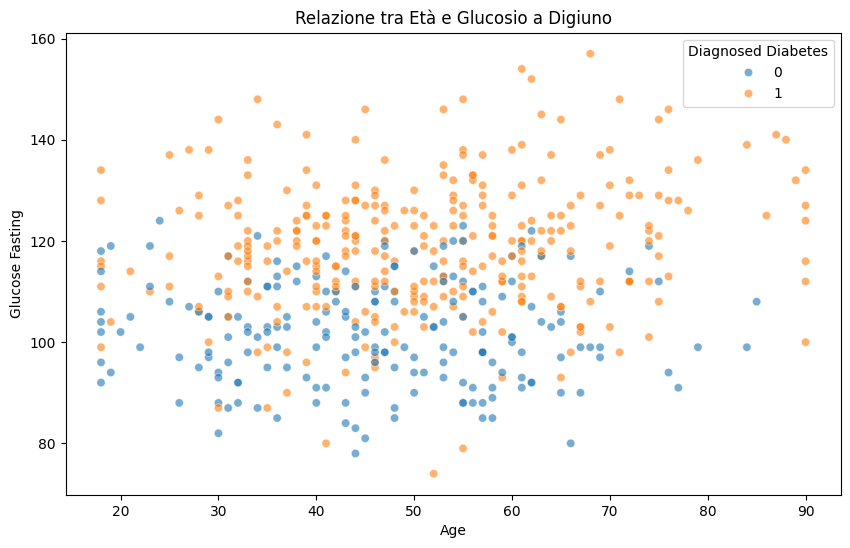

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Glucose Fasting', hue='Diagnosed Diabetes', data=df.sample(500), alpha=0.6)
plt.title('Relazione tra Età e Glucosio a Digiuno')
plt.show()

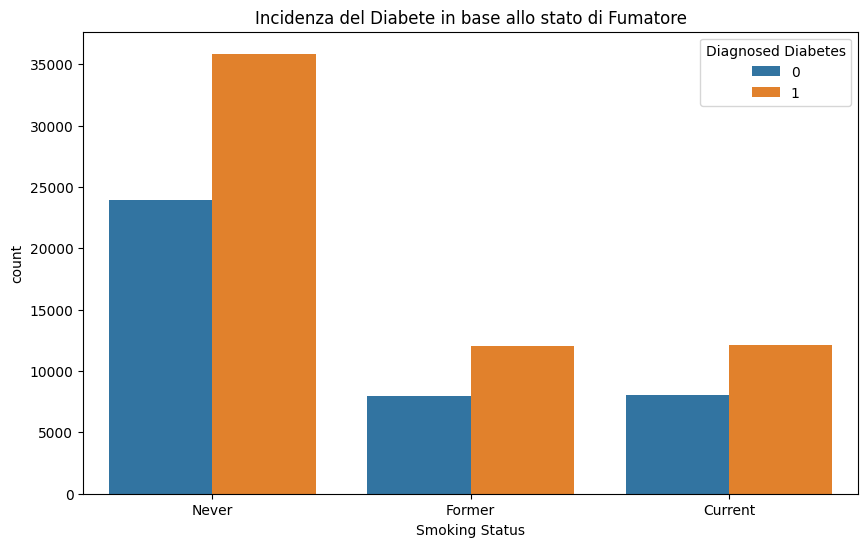

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Smoking Status', hue='Diagnosed Diabetes', data=df)
plt.title('Incidenza del Diabete in base allo stato di Fumatore')
plt.show()

In [24]:
# Creiamo le fasce d'età
bins = [0, 30, 50, 70, 100]
labels = ['Giovani', 'Adulti', 'Senior', 'Anziani']
df['Fascia Eta'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Vediamo subito quante diagnosi ci sono per fascia
print(df.groupby('Fascia Eta')['Diagnosed Diabetes'].sum())

Fascia Eta
Giovani     5384
Adulti     22574
Senior     24818
Anziani     7222
Name: Diagnosed Diabetes, dtype: int64


C:\Users\ogiug\AppData\Local\Temp\ipykernel_9792\348733803.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Fascia Eta')['Diagnosed Diabetes'].sum())


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepariamo i dati: vogliamo vedere come il BMI influenza il Diabetes Risk Score
X = df[['Bmi']].values 
y = df['Diabetes Risk Score'].values

# Creiamo e alleniamo il modello
model = LinearRegression()
model.fit(X, y)

# Facciamo una previsione: se un paziente ha un BMI di 35, quale sarà il suo rischio?
bmi_test = np.array([[35]])
rischio_predetto = model.predict(bmi_test)

print(f"Previsione: Un paziente con BMI 35 ha un rischio stimato di: {rischio_predetto[0]:.2f}")

# Il coefficiente
print(f"Per ogni punto di BMI in più, il rischio aumenta di: {model.coef_[0]:.2f}")

Previsione: Un paziente con BMI 35 ha un rischio stimato di: 37.66
Per ogni punto di BMI in più, il rischio aumenta di: 0.79


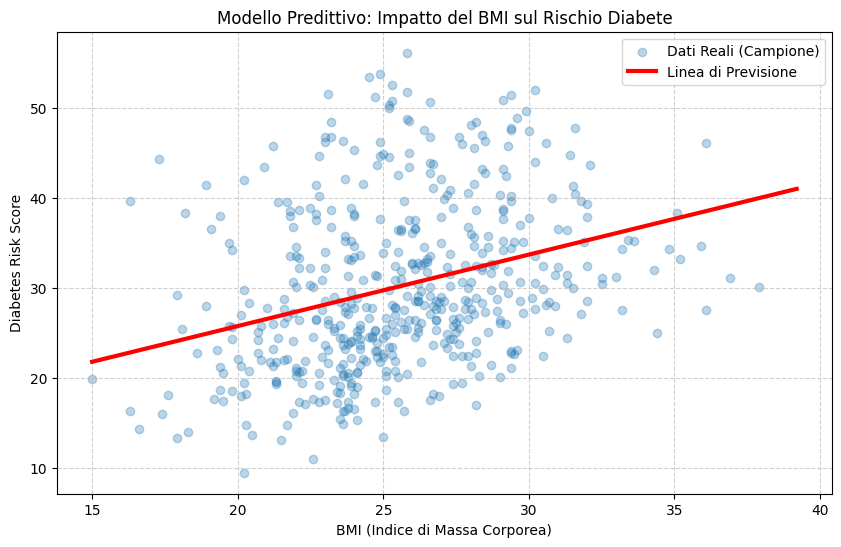

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Creiamo una serie di valori BMI ipotetici per tracciare la linea
x_range = np.linspace(df['Bmi'].min(), df['Bmi'].max(), 100).reshape(-1, 1)
y_pred_range = model.predict(x_range)

# 2. Creiamo il grafico
plt.figure(figsize=(10, 6))

# Disegniamo i punti reali (ne prendiamo un campione di 500 per non appesantire il grafico)
sample = df.sample(500)
plt.scatter(sample['Bmi'], sample['Diabetes Risk Score'], alpha=0.3, label='Dati Reali (Campione)')

# Disegniamo la linea della previsione 
plt.plot(x_range, y_pred_range, color='red', linewidth=3, label='Linea di Previsione')

plt.title('Modello Predittivo: Impatto del BMI sul Rischio Diabete')
plt.xlabel('BMI (Indice di Massa Corporea)')
plt.ylabel('Diabetes Risk Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

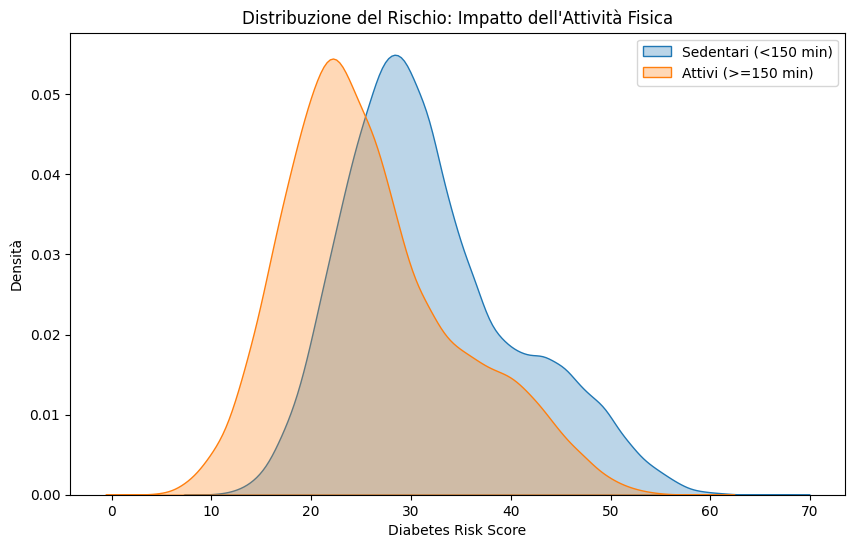

In [29]:
plt.figure(figsize=(10, 6))
# Confrontiamo la curva del rischio tra chi fa attività fisica e chi no
sns.kdeplot(data=df[df['Physical Activity Minutes Per Week'] < 150], x='Diabetes Risk Score', label='Sedentari (<150 min)', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Physical Activity Minutes Per Week'] >= 150], x='Diabetes Risk Score', label='Attivi (>=150 min)', fill=True, alpha=0.3)

plt.title('Distribuzione del Rischio: Impatto dell\'Attività Fisica')
plt.xlabel('Diabetes Risk Score')
plt.ylabel('Densità')
plt.legend()
plt.show()

In [30]:
# Salviamo il dataset lavorato in una nuova cartella per Power BI
df.to_csv('C:\\Users\\ogiug\\Documents\\healthcare project\\dashboard\\diabetes_cleaned_for_report.csv', index=False)
print("File pronto per Power BI!")

File pronto per Power BI!
